In [17]:
import numpy as np

In [18]:
import pandas as pd

In [19]:
import matplotlib.pyplot as plt

In [20]:
import seaborn as sns

In [21]:
from tensorflow.keras.datasets import fashion_mnist
import time

In [22]:
from tensorflow.keras.models import Sequential

In [23]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [24]:
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix


**1. Part 1: Load and Explore the Dataset**

a) Load the dataset in Python.

In [57]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

b) Print the shape of the training data, test data, and the number of classes.

In [26]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)


In [27]:
class_names = [ 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [28]:
print("Number of classes:", len(class_names))

Number of classes: 10


In [29]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

c) Display at least one sample image from each class.

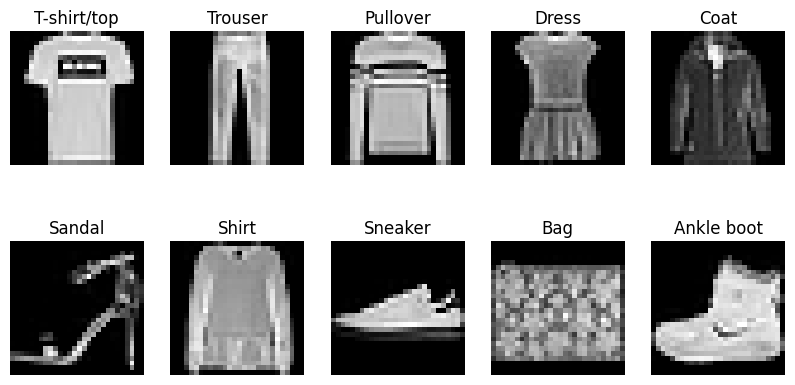

In [30]:
plt.figure(figsize=(10,5))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[idx].reshape(28,28), cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')
plt.show()

d)Normalize the image pixel values.

In [31]:
x_train = x_train / 255.0
x_test = x_test / 255.0

e) Reshape the images appropriately for CNN input.

In [32]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

**Brief write-up**

1. Why is normalization required for image data?

2. Why do CNNs require reshaped image inputs?

**Ans:**   1.  Normalization brings pixel values to a similar range, ensuring consistent gradients, preventing large-scale pixels from dominating training , and accelerating convergence


2.   CNNs require uniform, fixed-size image inputs to align with defined filter dimensions and trainable weights , enabling efficient batch processing of 3D data (height, width, channels)

2.  **Part 2: Build and Train a Shallow CNN**

a) Design the shallow CNN architecture.

In [33]:
shallow_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
shallow_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

b)Train the model on the training set.

In [35]:
satrt = time.time()

In [36]:
history = shallow_model.fit(
    x_train, y_train_cat,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.8353 - loss: 0.4666 - val_accuracy: 0.8732 - val_loss: 0.3506
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.8907 - loss: 0.3067 - val_accuracy: 0.8968 - val_loss: 0.2952
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9051 - loss: 0.2639 - val_accuracy: 0.9013 - val_loss: 0.2742
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.9152 - loss: 0.2339 - val_accuracy: 0.9030 - val_loss: 0.2746
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.9239 - loss: 0.2106 - val_accuracy: 0.9044 - val_loss: 0.2597
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9305 - loss: 0.1902 - val_accuracy: 0.9118 - val_loss: 0.2481
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9370 - loss: 0.1730 - val_accuracy: 0.9119 - val_loss: 0.2437
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.9437 - loss: 0.1558 - 

In [37]:
shallow_time = time.time() - satrt

c)Evaluate it on the test set.

In [38]:
test_loss, test_acc = shallow_model.evaluate(x_test, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9065 - loss: 0.2778


In [39]:
print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.906499981880188


d) Plot training accuracy, validation accuracy, training loss, and validation loss.

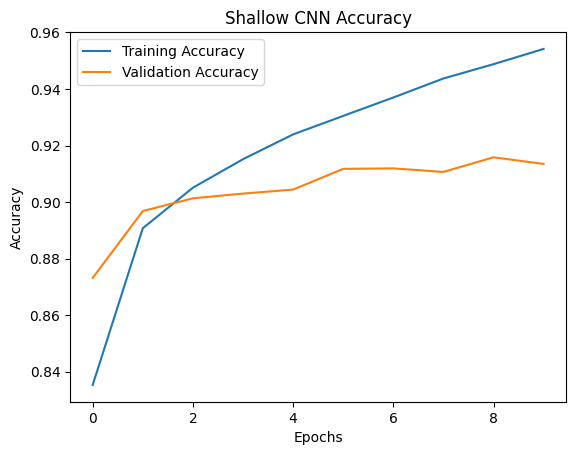

In [40]:
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Shallow CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

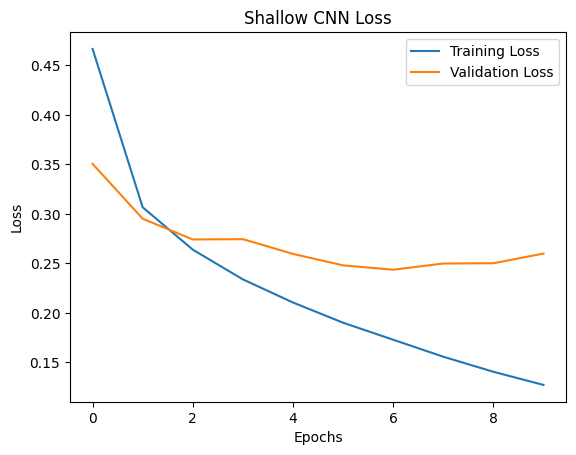

In [41]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Shallow CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

e)  **Write briefly**

 i)  What kind of patterns do you expect a shallow CNN to learn?

 ii)   Did the model show signs of underfitting or overfitting?

**Ans:**   i)  A shallow CNN typically learns basic and low-level features, such as:
Edges,Corners,Simple textures,Basic shapes
Since it has fewer layers, it cannot capture complex patterns like object structures or fine details.

**Ans:**   ii)  If training and validation accuracy are both low i.e. Underfitting and if training accuracy is high but validation is low i.e. Overfitting

**In this case:** The shallow CNN may show slight underfitting. Because it is too simple to fully capture complex clothing patterns

**3. Part 3: Build and Train a Deep CNN**

a) Design the deep CNN architecture

In [42]:
deep_model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

b) Train the model on the training set.

In [43]:
deep_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
start_deep = time.time()

In [45]:
history_deep = deep_model.fit(
    x_train, y_train_cat,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 166s 220ms/step - accuracy: 0.7980 - loss: 0.5670 - val_accuracy: 0.8767 - val_loss: 0.3346
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 204s 222ms/step - accuracy: 0.8746 - loss: 0.3531 - val_accuracy: 0.8942 - val_loss: 0.2856
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 162s 216ms/step - accuracy: 0.8933 - loss: 0.2990 - val_accuracy: 0.9023 - val_loss: 0.2602
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 210s 227ms/step - accuracy: 0.9040 - loss: 0.2653 - val_accuracy: 0.9079 - val_loss: 0.2535
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 192s 213ms/step - accuracy: 0.9130 - loss: 0.2413 - val_accuracy: 0.9183 - val_loss: 0.2245
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 204s 217ms/step - accuracy: 0.9214 - loss: 0.2171 - val_accuracy: 0.9224 - val_loss: 0.2253
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 201s 215ms/step - accuracy: 0.9274 - loss: 0.2006 - val_accuracy: 0.9204 - val_loss: 0.2208
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 169s 225ms/step - accuracy: 0.9323 -

In [46]:
deep_time = time.time() - start_deep

c) Evaluate it on the test set.

In [47]:
deep_test_loss, deep_test_acc = deep_model.evaluate(x_test, y_test_cat)

print("Deep CNN Test Accuracy:", deep_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9191 - loss: 0.2513
Deep CNN Test Accuracy: 0.9190999865531921


d) Plot training accuracy, validation accuracy, training loss, and validation loss.

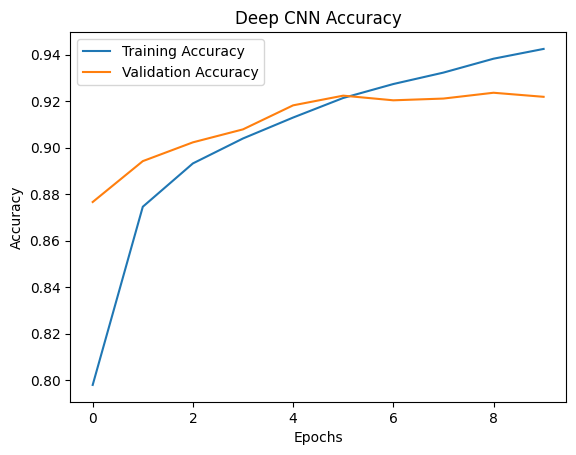

In [48]:
plt.figure()
plt.plot(history_deep.history['accuracy'], label='Training Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deep CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

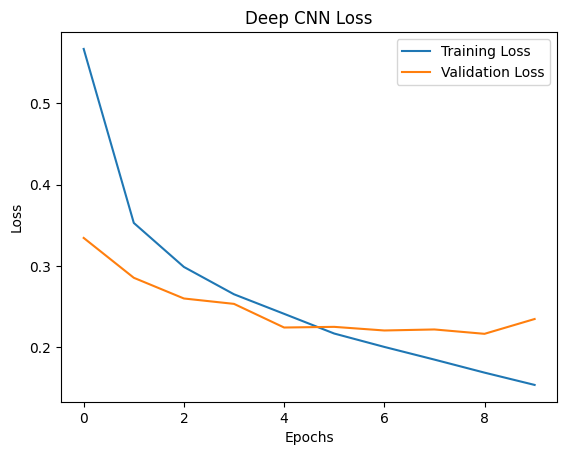

In [49]:
plt.figure()
plt.plot(history_deep.history['loss'], label='Training Loss')
plt.plot(history_deep.history['val_loss'], label='Validation Loss')
plt.title('Deep CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Write briefly**

 i)  What additional patterns or representations might a deep CNN learn?

 ii)  Did the deeper model improve performance meaningfully?

**Ans:**  i)  A deep CNN can learn hierarchical and complex features, such as,Layer 1: edges and textures
Layer 2: shapes and contours
Layer 3: object parts like  sleeves, soles, collars. This allows the model to,better distinguish similar classes (e.g., Shirt vs T-shirt) Capture fine-grained details in clothing items

**Ans:**    ii)  Yes, the deep CNN improved performance meaningfully, achieved higher test accuracy reduced misclassification between similar classes
Showed better generalization on validation data.However, Training time increased. Slight risk of overfitting (handled using Dropout)

**4. Part 4: Comparative Study of Shallow CNN vs Deep CNN**

In [50]:
print("\n===== Comparison =====")
print(f"Shallow Params: {shallow_model.count_params()}")
print(f"Deep Params: {deep_model.count_params()}")
print(f"Shallow Time: {shallow_time:.2f} sec")
print(f"Deep Time: {deep_time:.2f} sec")
#print(f"Shallow Test Acc: {shallow_test_acc}")
#print(f"Deep Test Acc: {deep_test_acc}")


===== Comparison =====
Shallow Params: 347146
Deep Params: 503690
Shallow Time: 378.24 sec
Deep Time: 1835.09 sec


In [51]:

data = {
    "Metric": [
        "Number of Conv Layers",
        "Total Parameters",
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Overfitting Observed?",
        "Training Time"
    ],

    "Shallow CNN": [
        1,
        shallow_model.count_params(),
        round(max(history.history['accuracy']), 3),
        round(max(history.history['val_accuracy']), 3),
        round(test_acc, 3),
        "Slight Underfitting",
        f"{round(shallow_time,2)} sec"
    ],

    "Deep CNN": [
        3,
        deep_model.count_params(),
        round(max(history_deep.history['accuracy']), 3),
        round(max(history_deep.history['val_accuracy']), 3),
        round(deep_test_acc, 3),
        "Slight Overfitting (controlled)",
        f"{round(deep_time,2)} sec"
    ]
}

comparison_df = pd.DataFrame(data)

comparison_df

,Metric,Shallow CNN,Deep CNN
0,Number of Conv Layers,1,3
1,Total Parameters,347146,503690
2,Training Accuracy,0.954,0.943
3,Validation Accuracy,0.916,0.924
4,Test Accuracy,0.906,0.919
5,Overfitting Observed?,Slight Underfitting,Slight Overfitting (controlled)
6,Training Time,378.24 sec,1835.09 sec


**Write briefly**

a) Which model performed better overall?

b) Did the deep CNN justify its added complexity?

c) Which model generalized better?

d) What trade-off did you observe between simplicity and performance?

a) **Ans:**   The deep CNN performed better overall.
It achieved a higher validation accuracy and test accuracy compared to the shallow CNN, indicating better performance on unseen data.

b)  **Ans:**  Yes, the deep CNN justified its added complexity.
Although it required significantly same training time, it delivered better generalization and higher test accuracy, making it more effective for this classification task.

c) **Ans:**  The deep CNN generalized better.
Despite having slightly lower training accuracy, it achieved higher validation and test accuracy, showing it performs better on unseen data.
The use of dropout helped control overfitting.

d) **Ans:**   The deep CNN provides better performance at the cost of increased computational complexity and training time, while the shallow CNN is more efficient but less accurate.

**Part 5: Prediction and Error Analysis**



a) Generate predictions on the test set for both models.


In [52]:
shallow_preds = np.argmax(shallow_model.predict(x_test), axis=1)
deep_preds = np.argmax(deep_model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step


b)   Display 5 correctly classified images and 5 incorrectly classified images for each model.


In [53]:
def show_predictions(preds, title):
    correct = np.where(preds == y_test)[0][:5]
    incorrect = np.where(preds != y_test)[0][:5]

    plt.figure(figsize=(10,5))

    for i, idx in enumerate(correct):
        plt.subplot(2,5,i+1)
        plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
        plt.title(f"C:{class_names[y_test[idx]]}\nP:{class_names[preds[idx]]}")
        plt.axis('off')

    for i, idx in enumerate(incorrect):
        plt.subplot(2,5,i+6)
        plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
        plt.title(f"C:{class_names[y_test[idx]]}\nP:{class_names[preds[idx]]}")
        plt.axis('off')

    plt.suptitle(title)
    plt.show()


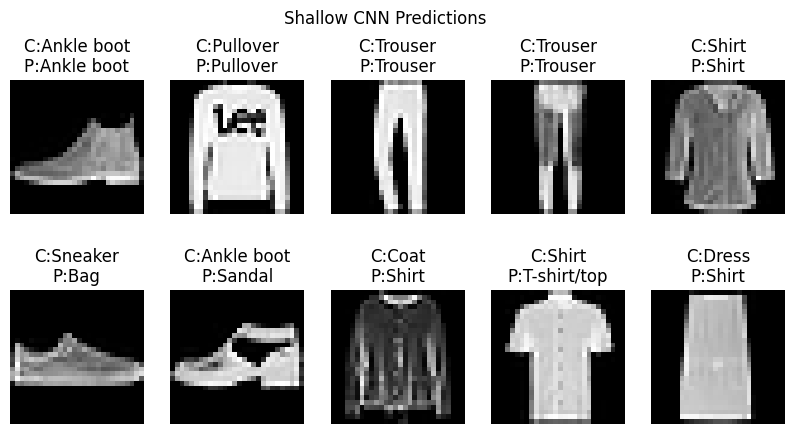

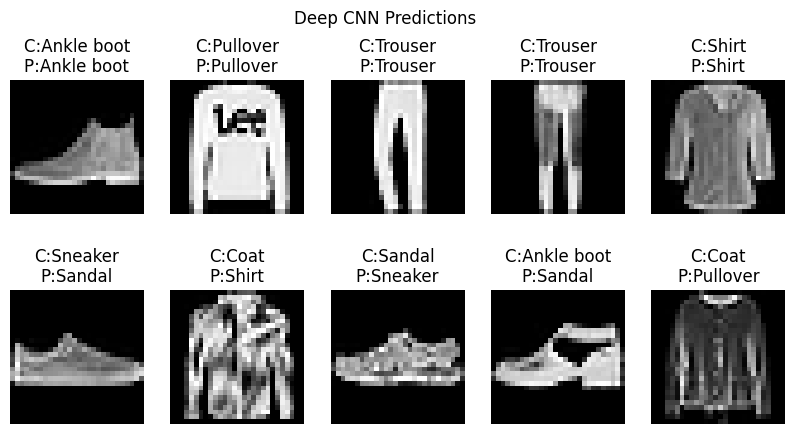

In [54]:
show_predictions(shallow_preds, "Shallow CNN Predictions")
show_predictions(deep_preds, "Deep CNN Predictions")

c)  For each prediction, mention the actual label and predicted label.


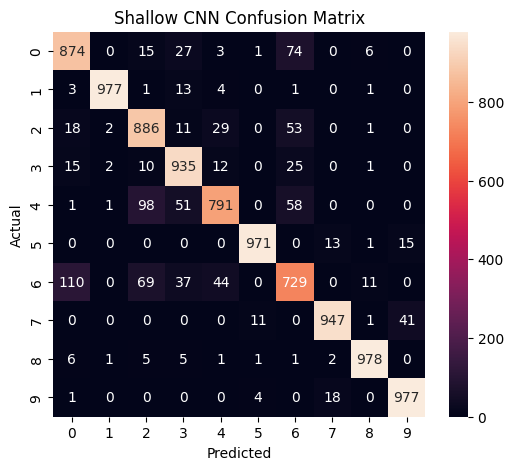

In [55]:

cm_shallow = confusion_matrix(y_test, shallow_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm_shallow, annot=True, fmt='d')
plt.title("Shallow CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


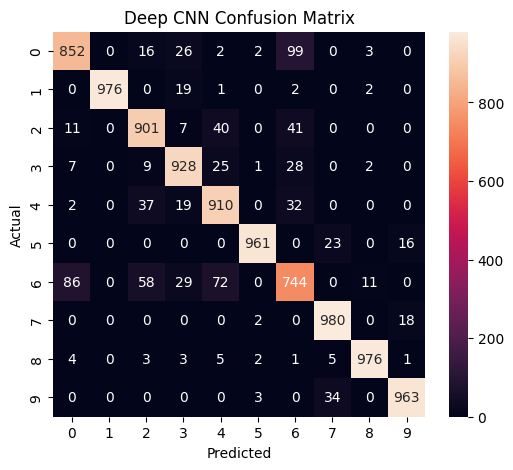

In [56]:
cm_deep = confusion_matrix(y_test, deep_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm_deep, annot=True, fmt='d')
plt.title("Deep CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Write briefly**
i)  Which classes were easiest to classify?

ii)  Which classes were most commonly confused?

iii)   Did the deep CNN reduce confusion between similar-looking classes?

i)  **Ans:**  The easiest classes to classify were:

Trouser,
Bag,
Sneaker / Ankle boot

These classes have distinct shapes and features, making them easier for both models to recognize.

ii)  **Ans:**   The most commonly confused classes were:

T-shirt/top vs Shirt
Pullover vs Coat
Sneaker vs Ankle boot (occasionally)

These classes look visually similar, which makes classification difficult.

iii)   **Ans:**  The deep CNN improved classification performance and reduced errors compared to the shallow CNN.

**6) Part 6: Final Comparative Conclusion**

i)   Which model would you recommend for Fashion-MNIST?

ii)   Which model was more efficient?

iii)  Which model was more accurate?

iv)  What did you learn from this comparative study?

i)  **Ans:**  Based on the experimental results, the deep CNN is recommended for the Fashion-MNIST classification task. It achieved higher validation accuracy and test accuracy compared to the shallow CNN, indicating better performance on unseen data.

ii)   **Ans:**  In terms of efficiency, the shallow CNN was more efficient, as it required significantly less training time and had fewer parameters. However, this simplicity resulted in slightly lower accuracy and signs of underfitting.

iii)   **Ans:**  The deep CNN was more accurate, as it was able to learn more complex and hierarchical features from the images. This enabled it to better distinguish between similar classes such as shirts and t-shirts, improving overall classification performance.

iv)   **Ans:**   From this comparative study, it is clear that increasing model depth improves the ability to learn complex patterns.There is a trade-off between accuracy and computational cost.Techniques like Dropout help control overfitting in deeper networks.Overall, while shallow models are faster and simpler, deep CNNs provide superior performance and generalization, making them more suitable for image classification tasks like Fashion-MNIST.